# Approach 2: ViSoBERT Fine-tuning for Multi-label Intent Classification

**Model:** `uitnlp/visobert` — pre-trained on informal Vietnamese social media text  
**Why ViSoBERT:** Natively understands teen code (`k`, `đc`, `sốp`), code-switching (English brand names), and informal writing styles without needing rule-based normalization.

| Design decision | Choice | Reason |
|---|---|---|
| Normalization | ❌ Skipped | ViSoBERT is trained on informal text — normalizing would discard signal it already understands |
| Multi-label augmentation | ✅ Applied | Data-level technique; improves co-occurring intent detection regardless of model |
| Handcrafted features | ❌ Skipped | BERT processes all tokens contextually; `?`, digits, politeness markers are already in the vocabulary |
| Loss function | BCEWithLogitsLoss | Treats each of the 32 classes as independent binary problems |
| Threshold | Per-class tuned on val | Same strategy as improved SVM — sigmoid probabilities allow principled threshold search |

**Prerequisite:** Run `data_preparation/data_split.ipynb` first.

In [1]:
# Requirements for this notebook
# See requirements.txt at the project root for the full list
!pip install torch transformers scikit-learn numpy pandas matplotlib seaborn joblib --quiet
!pip install hf_xet --quiet  # faster model downloads from Hugging Face

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [2]:
import json
import os
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import f1_score, hamming_loss, accuracy_score, classification_report

warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = '../final_data'
MODEL_NAME = 'uitnlp/visobert'

print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_NAME}')

c:\Users\Huawei\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cpu
Model  : uitnlp/visobert


## 1. Load Pre-split Data

In [3]:
def load_jsonl(path):
    texts, labels = [], []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            texts.append(item['text'])
            labels.append(item['cats'])
    return texts, labels

train_texts, train_labels = load_jsonl(f'{DATA_DIR}/train.jsonl')
val_texts,   val_labels   = load_jsonl(f'{DATA_DIR}/val.jsonl')
test_texts,  test_labels  = load_jsonl(f'{DATA_DIR}/test.jsonl')

mlb    = joblib.load(f'{DATA_DIR}/mlb.joblib')
y_train = mlb.transform(train_labels).astype(np.float32)
y_val   = mlb.transform(val_labels).astype(np.float32)
y_test  = mlb.transform(test_labels).astype(np.float32)

print(f'Train : {len(train_texts):4d} samples')
print(f'Val   : {len(val_texts):4d} samples')
print(f'Test  : {len(test_texts):4d} samples')
print(f'Labels: {len(mlb.classes_)} classes')

Train : 3605 samples
Val   :  454 samples
Test  :  450 samples
Labels: 32 classes


## 2. Multi-label Augmentation

Three complementary strategies, applied to the **training set only** (val and test are untouched):

1. **Multi-label duplication** — duplicate existing multi-label samples 2×.
2. **Rare class oversampling** — add 2 extra copies for any sample containing a class with < 80 training instances.
3. **Compositional augmentation** — synthesize new multi-label samples by joining two single-label sentences with a natural connector, directly teaching the model that rare intent combinations co-occur.

In [4]:
import random
random.seed(42)

# --- Step 1: Duplicate existing multi-label samples 2x ---
multi_idx    = [i for i, l in enumerate(train_labels) if len(l) > 1]
extra_texts  = [train_texts[i]  for i in multi_idx] * 2
extra_labels = [train_labels[i] for i in multi_idx] * 2

aug_texts  = train_texts + extra_texts
aug_labels = train_labels + extra_labels

print(f'Original train : {len(train_texts)}')
print(f'Multi-label    : {len(multi_idx)} → +{len(multi_idx) * 2} copies')

# --- Step 2: Rare class oversampling (<80 training samples) ---
RARE_THRESHOLD = 80
class_counts   = y_train.sum(axis=0)
rare_cls_idx   = np.where(class_counts < RARE_THRESHOLD)[0]
rare_cls_names = [mlb.classes_[i] for i in rare_cls_idx]

rare_texts, rare_label_lists = [], []
for text, lbl_vec, lbl_list in zip(train_texts, y_train, train_labels):
    if any(lbl_vec[j] == 1 for j in rare_cls_idx):
        rare_texts.extend([text] * 2)
        rare_label_lists.extend([lbl_list] * 2)

aug_texts  += rare_texts
aug_labels += rare_label_lists

print(f'Rare classes (<{RARE_THRESHOLD}): {rare_cls_names}')
print(f'Rare samples   : {len(rare_texts) // 2} unique → +{len(rare_texts)} copies')

# --- Step 3: Compositional augmentation ---
CONNECTORS   = [' với ', ' và ', ', ', ' luôn ', ' rồi ', ' thêm ']
TARGET_PAIRS = [
    ('ask_shipping_fee',         'ask_order_wait_time'),
    ('ask_product_suggestion',   'provide_budget'),
    ('ask_product_availability', 'ask_product_price'),
    ('ask_product_image',        'ask_product_price'),
]
N_PER_PAIR = 40

raw_by_intent = {}
for text, lbls in zip(train_texts, train_labels):
    if len(lbls) == 1:
        raw_by_intent.setdefault(lbls[0], []).append(text)

comp_texts, comp_labels = [], []
for a, b in TARGET_PAIRS:
    if a not in raw_by_intent or b not in raw_by_intent:
        print(f'  skip {a}+{b}: no single-label pool')
        continue
    for _ in range(N_PER_PAIR):
        ta = random.choice(raw_by_intent[a]).rstrip(' .?!,')
        tb = random.choice(raw_by_intent[b])
        comp_texts.append(ta + random.choice(CONNECTORS) + tb)
        comp_labels.append([a, b])

aug_texts  += comp_texts
aug_labels += comp_labels

print(f'Compositional  : {len(TARGET_PAIRS)} pairs × {N_PER_PAIR} = +{len(comp_texts)} samples')
print(f'Augmented total: {len(aug_texts)}')

Original train : 3605
Multi-label    : 387 → +774 copies
Rare classes (<80): ['ask_final_price', 'ask_find_product', 'ask_gift_package', 'ask_shipping_fee', 'customer_reject']
Rare samples   : 236 unique → +472 copies
Compositional  : 4 pairs × 40 = +160 samples
Augmented total: 5011


## 3. Random Token Masking

Randomly drops 15% of tokens per sample and adds one masked copy of the entire augmented set.
This prevents the model from over-fitting to specific trigger words and doubles the training data.

In [5]:
MASK_PROB = 0.15

def random_mask(text: str, mask_prob: float = MASK_PROB, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    tokens = text.split()
    kept = [t for t in tokens if rng.random() > mask_prob]
    return ' '.join(kept) if kept else text   # never return empty string

rng = np.random.default_rng(42)
masked_texts = [random_mask(t, rng=rng) for t in aug_texts]

masked_train_texts  = aug_texts + masked_texts
masked_train_labels = aug_labels + aug_labels
y_masked = mlb.transform(masked_train_labels).astype(np.float32)

print(f'Augmented train : {len(aug_texts)}')
print(f'After masking   : {len(masked_train_texts)} (1 masked copy added)')
print(f'\nExample:')
print(f'  Original: {aug_texts[0]}')
print(f'  Masked  : {masked_texts[0]}')

Augmented train : 5011
After masking   : 10022 (1 masked copy added)

Example:
  Original: Chị ưu tiên gửi batch mới nhất giúp em.
  Masked  : Chị ưu tiên gửi mới nhất giúp


## 3. Tokenizer and DataLoaders

The tokenizer converts raw text into token IDs. Padding and truncation are handled dynamically per batch (dynamic padding = shorter average sequence → faster training).  
`MAX_LEN=128` is sufficient for short customer chat messages.

In [6]:
MAX_LEN    = 128
BATCH_SIZE = 16   # reduce to 8 if GPU runs out of memory

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Vocab size: {tokenizer.vocab_size:,}')

class IntentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = texts
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

def collate_fn(batch):
    texts, labels = zip(*batch)
    encoding = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )
    return encoding, torch.stack(labels)

train_ds = IntentDataset(masked_train_texts, y_masked)   # use masked + augmented set
val_ds   = IntentDataset(val_texts,          y_val)
test_ds  = IntentDataset(test_texts,         y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

Vocab size: 15,002
Train batches: 627
Val batches  : 29
Test batches : 29


## 4. Model

`AutoModelForSequenceClassification` with `problem_type='multi_label_classification'` automatically:
- Sets the output to `num_labels` logits
- Uses `BCEWithLogitsLoss` when labels are provided during the forward pass

At inference, `sigmoid(logits)` converts each logit to an independent probability in `[0, 1]`.

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(mlb.classes_),
    problem_type='multi_label_classification',
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 556.03it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: uitnlp/visobert
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 97,590,560
Trainable parameters: 97,590,560


## 5. Training

| Hyperparameter | Value | Reason |
|---|---|---|
| Learning rate | 2e-5 | Standard for BERT fine-tuning; higher rates destabilise pre-trained weights |
| Epochs | 10 (early stopping patience=3) | Stops automatically when val Macro-F1 stops improving |
| Warmup | 10% of total steps | Prevents large gradient updates at the start |
| Gradient clipping | 1.0 | Stabilises training on small datasets |
| Scheduler | Linear decay | Gradually reduces LR after warmup |

In [8]:
EPOCHS       = 10
LR           = 2e-5
WARMUP_RATIO = 0.1
PATIENCE     = 3

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'Total steps  : {total_steps}')
print(f'Warmup steps : {warmup_steps}')

Total steps  : 6270
Warmup steps : 627


In [9]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    for encoding, labels in loader:
        encoding = {k: v.to(device) for k, v in encoding.items()}
        labels   = labels.to(device)

        outputs = model(**encoding, labels=labels)
        loss    = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device, thresholds=0.5):
    model.eval()
    all_proba, all_labels = [], []
    with torch.no_grad():
        for encoding, labels in loader:
            encoding = {k: v.to(device) for k, v in encoding.items()}
            logits   = model(**encoding).logits
            proba    = torch.sigmoid(logits).cpu().numpy()
            all_proba.append(proba)
            all_labels.append(labels.numpy())

    all_proba  = np.vstack(all_proba)
    all_labels = np.vstack(all_labels)
    preds      = (all_proba >= thresholds).astype(int)
    macro_f1   = f1_score(all_labels, preds, average='macro', zero_division=0)
    return macro_f1, all_proba, all_labels

In [10]:
train_losses  = []
val_macro_f1s = []
best_val_f1   = 0.0
best_epoch    = 0
no_improve    = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_f1, _, _ = evaluate(model, val_loader, DEVICE, thresholds=0.5)

    train_losses.append(train_loss)
    val_macro_f1s.append(val_f1)

    improved = val_f1 > best_val_f1
    if improved:
        best_val_f1 = val_f1
        best_epoch  = epoch
        no_improve  = 0
        torch.save(model.state_dict(), 'results/best_model.pt')
    else:
        no_improve += 1

    flag = ' *saved*' if improved else ''
    print(f'Epoch {epoch:2d}/{EPOCHS}  |  Train Loss: {train_loss:.4f}  |  Val Macro-F1: {val_f1:.4f}{flag}')

    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).')
        break

print(f'\nBest Val Macro-F1: {best_val_f1:.4f} at epoch {best_epoch}')

Epoch  1/10  |  Train Loss: 0.2735  |  Val Macro-F1: 0.0501 *saved*
Epoch  2/10  |  Train Loss: 0.1007  |  Val Macro-F1: 0.5229 *saved*
Epoch  3/10  |  Train Loss: 0.0483  |  Val Macro-F1: 0.7873 *saved*
Epoch  4/10  |  Train Loss: 0.0269  |  Val Macro-F1: 0.8529 *saved*
Epoch  5/10  |  Train Loss: 0.0178  |  Val Macro-F1: 0.8658 *saved*
Epoch  6/10  |  Train Loss: 0.0131  |  Val Macro-F1: 0.8743 *saved*
Epoch  7/10  |  Train Loss: 0.0102  |  Val Macro-F1: 0.8765 *saved*
Epoch  8/10  |  Train Loss: 0.0085  |  Val Macro-F1: 0.8754
Epoch  9/10  |  Train Loss: 0.0073  |  Val Macro-F1: 0.8639
Epoch 10/10  |  Train Loss: 0.0068  |  Val Macro-F1: 0.8746

Early stopping at epoch 10 (no improvement for 3 epochs).

Best Val Macro-F1: 0.8765 at epoch 7


## 6. Training Curves

Plots **train loss** and **val Macro-F1** per epoch — the neural network equivalent of a learning curve.

- Train loss should decrease steadily
- Val F1 should increase then plateau (early stopping catches the peak)
- A rising val F1 gap relative to train loss = overfitting

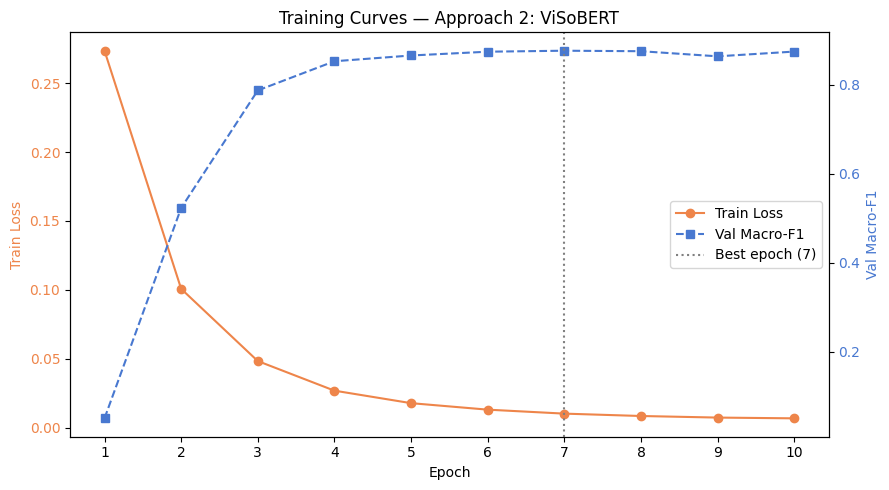

In [11]:
epochs_ran = range(1, len(train_losses) + 1)

fig, ax1 = plt.subplots(figsize=(9, 5))

color_loss = '#ee854a'
color_f1   = '#4878d0'

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color_loss)
ax1.plot(epochs_ran, train_losses, 'o-', color=color_loss, label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.set_xticks(list(epochs_ran))

ax2 = ax1.twinx()
ax2.set_ylabel('Val Macro-F1', color=color_f1)
ax2.plot(epochs_ran, val_macro_f1s, 's--', color=color_f1, label='Val Macro-F1')
ax2.tick_params(axis='y', labelcolor=color_f1)
ax2.axvline(best_epoch, color='gray', linestyle=':', linewidth=1.5,
            label=f'Best epoch ({best_epoch})')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Training Curves — Approach 2: ViSoBERT')
fig.tight_layout()
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-class Threshold Tuning

Load the best saved checkpoint and search for the optimal threshold per class on the validation set.  
Same strategy as the improved SVM — sigmoid probabilities in `[0,1]` make the search principled.

In [12]:
# Load best checkpoint
model.load_state_dict(torch.load('results/best_model.pt', map_location=DEVICE))
model.eval()

_, val_proba, val_true = evaluate(model, val_loader, DEVICE, thresholds=0.5)

thresholds = []
for i, cls in enumerate(mlb.classes_):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.10, 0.95, 0.05):
        preds = (val_proba[:, i] >= t).astype(int)
        f1    = f1_score(val_true[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    thresholds.append(best_t)

df_thresh = pd.DataFrame({'Class': mlb.classes_, 'Threshold': thresholds})
print(df_thresh.to_string(index=False))

                    Class  Threshold
                  Goodbye       0.25
              add_product       0.90
                    agree       0.50
              agree_order       0.25
          ask_final_price       0.75
         ask_find_product       0.10
         ask_gift_package       0.10
                ask_legit       0.10
         ask_order_status       0.10
      ask_order_wait_time       0.30
       ask_payment_method       0.45
 ask_product_availability       0.85
        ask_product_image       0.50
         ask_product_info       0.15
        ask_product_price       0.45
   ask_product_suggestion       0.10
         ask_shipping_fee       0.75
            ask_shop_info       0.10
               buy_thanks       0.25
  complain_shipping_issue       0.60
         confirm_received       0.10
          customer_reject       0.10
delivery_time_requirement       0.25
       get_product_direct       0.90
             give_product       0.50
                 greeting       0.70
 

## 8. Evaluate on Test Set

In [13]:
_, test_proba, test_true = evaluate(model, test_loader, DEVICE, thresholds=0.5)
y_pred = (test_proba >= np.array(thresholds)).astype(int)

macro_f1   = f1_score(test_true, y_pred, average='macro',  zero_division=0)
micro_f1   = f1_score(test_true, y_pred, average='micro',  zero_division=0)
h_loss     = hamming_loss(test_true, y_pred)
subset_acc = accuracy_score(test_true, y_pred)

print('=' * 50)
print('TEST RESULTS — Approach 2: ViSoBERT')
print('=' * 50)
print(f'Macro-F1        : {macro_f1:.4f}')
print(f'Micro-F1        : {micro_f1:.4f}')
print(f'Hamming Loss    : {h_loss:.4f}')
print(f'Subset Accuracy : {subset_acc:.4f}')

TEST RESULTS — Approach 2: ViSoBERT
Macro-F1        : 0.8933
Micro-F1        : 0.8871
Hamming Loss    : 0.0078
Subset Accuracy : 0.8222


In [14]:
print(classification_report(test_true, y_pred, target_names=mlb.classes_, zero_division=0))

                           precision    recall  f1-score   support

                  Goodbye       1.00      0.91      0.95        11
              add_product       1.00      0.91      0.95        11
                    agree       1.00      0.70      0.82        20
              agree_order       0.94      0.94      0.94        17
          ask_final_price       1.00      1.00      1.00         6
         ask_find_product       1.00      0.50      0.67         4
         ask_gift_package       0.75      1.00      0.86         6
                ask_legit       1.00      1.00      1.00        10
         ask_order_status       0.82      1.00      0.90        23
      ask_order_wait_time       1.00      0.83      0.91        12
       ask_payment_method       1.00      1.00      1.00        17
 ask_product_availability       0.96      0.92      0.94        26
        ask_product_image       1.00      1.00      1.00        13
         ask_product_info       0.92      0.92      0.92     

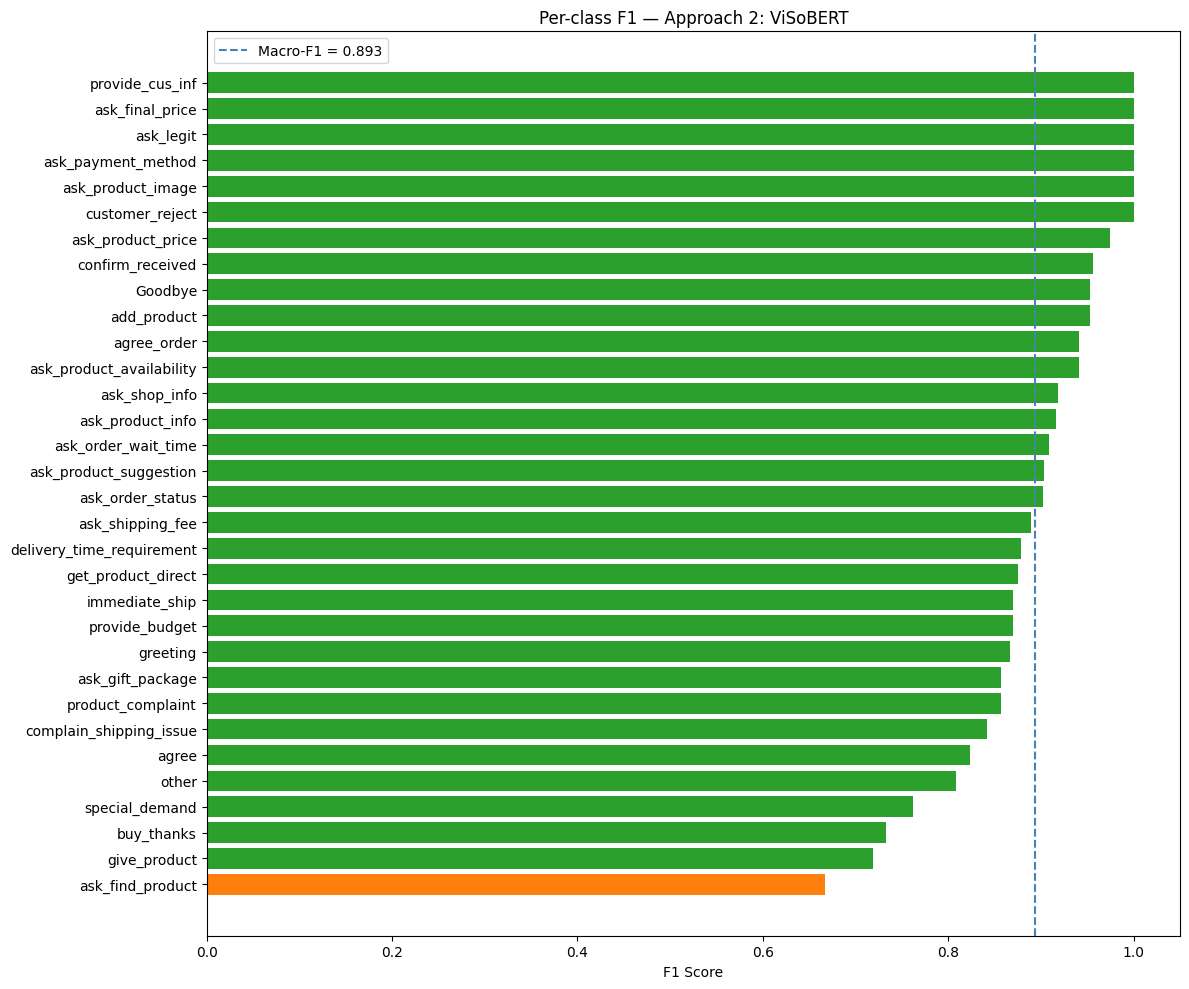

Lowest F1 : ask_find_product  (0.667)
Highest F1: provide_cus_inf (1.000)


In [15]:
per_class_f1 = f1_score(test_true, y_pred, average=None, zero_division=0)
df_f1 = pd.DataFrame({'Label': mlb.classes_, 'F1': per_class_f1}).sort_values('F1', ascending=True)

colors = ['#d62728' if f < 0.5 else '#ff7f0e' if f < 0.7 else '#2ca02c' for f in df_f1['F1']]
plt.figure(figsize=(12, 10))
plt.barh(df_f1['Label'], df_f1['F1'], color=colors)
plt.axvline(macro_f1, color='steelblue', linestyle='--', linewidth=1.5,
            label=f'Macro-F1 = {macro_f1:.3f}')
plt.xlabel('F1 Score')
plt.title('Per-class F1 — Approach 2: ViSoBERT')
plt.legend()
plt.tight_layout()
plt.savefig('results/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Lowest F1 : {df_f1.iloc[0]['Label']}  ({df_f1.iloc[0]['F1']:.3f})")
print(f"Highest F1: {df_f1.iloc[-1]['Label']} ({df_f1.iloc[-1]['F1']:.3f})")

## 9. Save Model and Results

In [16]:
# Save tokenizer alongside model for reproducible inference
tokenizer.save_pretrained('results/tokenizer')

metrics = {
    'approach'        : 'ViSoBERT',
    'model_name'      : MODEL_NAME,
    'best_epoch'      : best_epoch,
    'best_val_macro_f1': round(best_val_f1, 4),
    'thresholds'      : {k: round(float(v), 4) for k, v in zip(mlb.classes_, thresholds)},
    'macro_f1'        : round(macro_f1,   4),
    'micro_f1'        : round(micro_f1,   4),
    'hamming_loss'    : round(h_loss,     4),
    'subset_accuracy' : round(subset_acc, 4),
    'per_class_f1'    : {k: round(float(v), 4) for k, v in zip(mlb.classes_, per_class_f1)},
    'train_losses'    : [round(x, 4) for x in train_losses],
    'val_macro_f1s'   : [round(x, 4) for x in val_macro_f1s],
}

with open('results/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print('Saved to approach2/results/:')
for name in ['best_model.pt', 'tokenizer/', 'metrics.json',
             'training_curves.png', 'per_class_f1.png']:
    print(f'  {name}')

Saved to approach2/results/:
  best_model.pt
  tokenizer/
  metrics.json
  training_curves.png
  per_class_f1.png


## 10. Test Custom Input

Reloads the best checkpoint and tokenizer from `results/` — works after a kernel restart.

In [17]:
import json, datetime
import numpy as np
import torch
import joblib
from transformers import AutoTokenizer, AutoModelForSequenceClassification

_device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_tokenizer = AutoTokenizer.from_pretrained('results/tokenizer')
_mlb       = joblib.load('../final_data/mlb.joblib')

_model = AutoModelForSequenceClassification.from_pretrained(
    'uitnlp/visobert',
    num_labels=len(_mlb.classes_),
    problem_type='multi_label_classification',
    ignore_mismatched_sizes=True,
)
_model.load_state_dict(torch.load('results/best_model.pt', map_location=_device))
_model = _model.to(_device)
_model.eval()

with open('results/metrics.json', encoding='utf-8') as f:
    _thresholds = np.array(list(json.load(f)['thresholds'].values()))

_prediction_log = []

def predict(text: str, top_k: int = 3):
    enc = _tokenizer(
        text, truncation=True, padding=True,
        max_length=128, return_tensors='pt'
    )
    enc = {k: v.to(_device) for k, v in enc.items()}

    with torch.no_grad():
        logits = _model(**enc).logits
    proba  = torch.sigmoid(logits).cpu().numpy()[0]

    predicted = tuple(cls for cls, p, t in zip(_mlb.classes_, proba, _thresholds) if p >= t)
    ranked    = sorted(zip(_mlb.classes_, proba), key=lambda x: -x[1])

    _prediction_log.append({
        'timestamp' : datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'input'     : text,
        'predicted' : list(predicted),
        'top_proba' : {label: round(float(p), 4) for label, p in ranked[:top_k]},
    })

    print(f'Input     : {text}')
    print(f'Predicted : {list(predicted) if predicted else "[none above threshold]"}')
    print(f'Top {top_k} probabilities:')
    for label, prob in ranked[:top_k]:
        marker = ' <--' if label in predicted else ''
        print(f'  {label:<35} {prob:.3f}{marker}')

print('predict() ready.  History log is in _prediction_log.')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 21888.16it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: uitnlp/visobert
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


predict() ready.  History log is in _prediction_log.


In [18]:
# ── Change this text and re-run ──────────────────────────────────────────────
predict('sốp ơi còn hàng con ferrari k ạ')

Input     : sốp ơi còn hàng con ferrari k ạ
Predicted : ['ask_product_availability']
Top 3 probabilities:
  ask_product_availability            0.965 <--
  give_product                        0.040
  ask_product_price                   0.008


In [19]:
samples = [
    'shop ơi',
    'bao g có hàng thế ạ',
    'cho e đặt màu xanh với ạ',
    'giá con này bao nhiêu vậy shop',
]
for text in samples:
    print('-' * 55)
    predict(text, top_k=2)
print('-' * 55)

-------------------------------------------------------
Input     : shop ơi
Predicted : ['greeting']
Top 2 probabilities:
  greeting                            0.938 <--
  agree                               0.011
-------------------------------------------------------
Input     : bao g có hàng thế ạ
Predicted : ['ask_order_status', 'ask_order_wait_time']
Top 2 probabilities:
  ask_order_status                    0.777 <--
  ask_order_wait_time                 0.394 <--
-------------------------------------------------------
Input     : cho e đặt màu xanh với ạ
Predicted : ['agree_order']
Top 2 probabilities:
  agree_order                         0.950 <--
  ask_payment_method                  0.031
-------------------------------------------------------
Input     : giá con này bao nhiêu vậy shop
Predicted : ['ask_product_price']
Top 2 probabilities:
  ask_product_price                   0.959 <--
  give_product                        0.012
---------------------------------------------

## 11. Prediction History Log

Every `predict()` call is recorded in `_prediction_log` (in-memory).

- `show_log()` — print history as a table
- `save_log()` — append new entries to `results/prediction_log.jsonl`
- `clear_log()` — wipe in-memory log (saved file is untouched)

In [20]:
def show_log(n=None):
    entries = _prediction_log if n is None else _prediction_log[-n:]
    if not entries:
        print('Log is empty — run predict() first.')
        return
    print(f'{"#":<4} {"Timestamp":<20} {"Input":<40} {"Predicted"}')
    print('-' * 100)
    for i, e in enumerate(entries):
        idx   = len(_prediction_log) - len(entries) + i + 1
        inp   = e['input'][:38] + '..' if len(e['input']) > 40 else e['input']
        preds = ', '.join(e['predicted']) if e['predicted'] else '[none]'
        print(f'{idx:<4} {e["timestamp"]:<20} {inp:<40} {preds}')
    print(f'\nTotal entries: {len(_prediction_log)}')

show_log()

#    Timestamp            Input                                    Predicted
----------------------------------------------------------------------------------------------------
1    2026-06-24 05:31:14  sốp ơi còn hàng con ferrari k ạ          ask_product_availability
2    2026-06-24 05:31:14  shop ơi                                  greeting
3    2026-06-24 05:31:14  bao g có hàng thế ạ                      ask_order_status, ask_order_wait_time
4    2026-06-24 05:31:14  cho e đặt màu xanh với ạ                 agree_order
5    2026-06-24 05:31:14  giá con này bao nhiêu vậy shop           ask_product_price

Total entries: 5


In [21]:
LOG_PATH = 'results/prediction_log.jsonl'

def save_log(path=LOG_PATH, mode='append'):
    if not _prediction_log:
        print('Nothing to save.')
        return
    if mode == 'append':
        existing = set()
        try:
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    e = json.loads(line)
                    existing.add((e['timestamp'], e['input']))
        except FileNotFoundError:
            pass
        new = [e for e in _prediction_log if (e['timestamp'], e['input']) not in existing]
        with open(path, 'a', encoding='utf-8') as f:
            for e in new:
                json.dump(e, f, ensure_ascii=False)
                f.write('\n')
        print(f'Appended {len(new)} entries → {path}')
    else:
        with open(path, 'w', encoding='utf-8') as f:
            for e in _prediction_log:
                json.dump(e, f, ensure_ascii=False)
                f.write('\n')
        print(f'Saved {len(_prediction_log)} entries → {path}')

def clear_log():
    count = len(_prediction_log)
    _prediction_log.clear()
    print(f'Cleared {count} entries.')

# ── Usage ─────────────────────────────────────────────────────────────────────
# save_log()                 # append new entries
# save_log(mode='overwrite') # replace the file
# show_log(n=5)              # last 5 entries
# clear_log()                # wipe in-memory log
print('save_log() / clear_log() ready.')

save_log() / clear_log() ready.
